# Data Understanding & Preparation - Microbiology Events
## Essential Features for Cardiac Patient Clustering

## Overview

This notebook extracts **clinically relevant microbiological features** from the `Microbiology Events` table at the **admission level** (subject_id, hadm_id) for building the patient profiles.

## Data Understanding and Preparation

According to the project guidelines, this phase involves:
1. **Data Understanding**: Assessing data quality, identifying missing values, exploring distributions, and understanding the clinical context.
2. **Data Preparation**: Cleaning data, handling missing values, creating new features (Feature Engineering), and transforming data into a suitable format for clustering.

In this notebook, we focus on the **Microbiology Events** table to extract indicators of infection severity and antimicrobial resistance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

# Data Understanding

The first step is to load the dataset and perform an initial assessment of its structure and quality.

In [2]:
# Load data
df = pd.read_csv(Path().resolve().parent / 'Data' / 'microbiology_events_codes_3.csv')

print("="*80)
print("INITIAL DATA ASSESSMENT")
print("="*80)
print(f"\nDataset shape: {df.shape[0]:,} records × {df.shape[1]} columns")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\n{'='*80}")
print("First few rows:")
print("="*80)
display(df.head(3))

INITIAL DATA ASSESSMENT

Dataset shape: 15,587 records × 14 columns

Column names and types:
subject_id               int64
hadm_id                float64
chartdate               object
charttime               object
spec_type_desc          object
test_name               object
org_name                object
ab_name                 object
dilution_text           object
dilution_comparison     object
dilution_value         float64
interpretation          object
technician_id           object
qc_flag                 object
dtype: object

First few rows:


,subject_id,hadm_id,chartdate,charttime,spec_type_desc,test_name,org_name,ab_name,dilution_text,dilution_comparison,dilution_value,interpretation,technician_id,qc_flag
0,10000980,26913865.0,2189-06-27 00:00:00,2189-06-27 10:52:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_063,QC_OK
1,10002155,23822395.0,2129-08-04 00:00:00,2129-08-04 17:04:00,MRSA SCREEN,MRSA SCREEN,NaN,NaN,NaN,NaN,NaN,NaN,TECH_095,QC_OK
2,10002155,23822395.0,2129-08-05 00:00:00,2129-08-05 15:54:00,URINE,Legionella Urinary Antigen,NaN,NaN,NaN,NaN,NaN,NaN,TECH_083,QC_OK


## Data Quality Assessment

We check for:
- **Missing Values**: Crucial for understanding which features can be reliably used.
- **Duplicates**: To avoid bias in the analysis.
- **Data Types**: Ensuring columns are in the correct format for analysis.

In [3]:
# Missing values
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_counts, 'Percentage': missing_percent})
print("\nMissing Values Analysis:")
print(missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage', ascending=False))

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")
if duplicates > 0:
    print("Dropping duplicates...")
    df.drop_duplicates(inplace=True)
    print(f"New shape: {df.shape}")


Missing Values Analysis:
                     Missing Values  Percentage
dilution_value                10876   69.776095
dilution_comparison           10876   69.776095
dilution_text                 10874   69.763264
ab_name                       10767   69.076795
interpretation                10767   69.076795
org_name                      10196   65.413486

Number of duplicate rows: 1
Dropping duplicates...
New shape: (15586, 14)


In [4]:
def identify_hadm_id_duplicates(df):
    """
    Identify rows where the same hadm_id is associated with multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to analyze
    
    Returns:
        pd.Series: Series with problematic hadm_id and number of distinct subject_id
    """
    if 'hadm_id' not in df.columns.tolist() or 'subject_id' not in df.columns.tolist():
        return pd.Series()
    
    hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
    problematic = hadm_id_counts[hadm_id_counts > 1]
    
    return problematic


In [5]:
def clean_duplicate_admissions(df):
    """
    Remove rows where the same hadm_id is associated with multiple subject_id.
    
    Args:
        df (pd.DataFrame): Dataframe to clean
    
    Returns:
        pd.DataFrame: Cleaned dataframe
        dict: Cleaning statistics
    """
    original_shape = df.shape
    
    # Keep only hadm_id with a single subject_id
    df_cleaned = df.groupby('hadm_id').filter(
        lambda x: x['subject_id'].nunique() == 1
    )
    
    rows_removed = len(df) - len(df_cleaned)
    
    stats = {
        'original_shape': original_shape,
        'cleaned_shape': df_cleaned.shape,
        'rows_removed': rows_removed,
        'percentage_removed': (rows_removed / len(df) * 100) if len(df) > 0 else 0
    }
    
    return df_cleaned, stats

In [6]:
def verify_cleaning(df):
    """
    Verify that the dataframe no longer contains hadm_id->subject_id duplicates.
    
    Args:
        df (pd.DataFrame): Dataframe to verify
    
    Returns:
        bool: True if clean, False otherwise
        int: Number of hadm_id still problematic
    """
    if 'hadm_id' not in df.columns or 'subject_id' not in df.columns:
        return False, -1
    
    hadm_id_counts = df.groupby('hadm_id')['subject_id'].nunique()
    problematic = hadm_id_counts[hadm_id_counts > 1]
    
    is_clean = len(problematic) == 0
    
    return is_clean, len(problematic)

In [7]:
def validate_complete_dataset(df):
    """
    Main function that orchestrates the entire validation and cleaning process.
    
    Args:
        df (pd.DataFrame): Dataframe to validate and clean
    
    Returns:
        pd.DataFrame: Cleaned dataframe
        dict: Complete validation report
    """
    
    report = {}
    
    problematic = identify_hadm_id_duplicates(df)
    
    report['problematic_hadm_id'] = len(problematic)
    report['estimated_affected_rows'] = df[df['hadm_id'].isin(problematic.index)].shape[0] if len(problematic) > 0 else 0
    
    if len(problematic) > 0:
        # Show examples
        print(f"\n  Examples of problematic hadm_id:")
        for hadm_id, n_subjects in problematic.head(5).items():
            example_subjects = df[df['hadm_id'] == hadm_id]['subject_id'].unique()
            print(f"    • hadm_id {hadm_id}: {n_subjects} distinct subject_id {list(example_subjects)[:3]}")
    else:
        print("  ✅ No duplicates found")
        report['cleaning_needed'] = False
        report['df_cleaned'] = df
        return df, report
    
    # 2. Clean dataframe
    report['cleaning_needed'] = True
    df_cleaned, cleaning_stats = clean_duplicate_admissions(df)
    report.update(cleaning_stats)
    
    # 3. Verify cleaning
    is_clean, n_remaining = verify_cleaning(df_cleaned)
    report['validation_success'] = is_clean
    report['remaining_problematic_hadm_id'] = n_remaining
    
    print(f"  Unique hadm_id (after): {df_cleaned['hadm_id'].nunique()}")
    print(f"  Unique subject_id (after): {df_cleaned['subject_id'].nunique()}")
    print(f"  Total rows (after): {len(df_cleaned)}")
    
    report['df_cleaned'] = df_cleaned
    
    return df_cleaned, report

In [8]:
# Run complete validation
df_validated, report = validate_complete_dataset(df)

# Replace original dataframe with validated one
df = df_validated


  Examples of problematic hadm_id:
    • hadm_id 20007905.0: 3 distinct subject_id [np.int64(13709807), np.int64(19997460), np.int64(19997485)]
    • hadm_id 20095782.0: 2 distinct subject_id [np.int64(17443221), np.int64(19997450)]
    • hadm_id 20097155.0: 2 distinct subject_id [np.int64(18048134), np.int64(19997631)]
    • hadm_id 20113266.0: 2 distinct subject_id [np.int64(13933090), np.int64(19997491)]
    • hadm_id 20205373.0: 2 distinct subject_id [np.int64(17844820), np.int64(19997544)]
  Unique hadm_id (after): 2198
  Unique subject_id (after): 2082
  Total rows (after): 11458


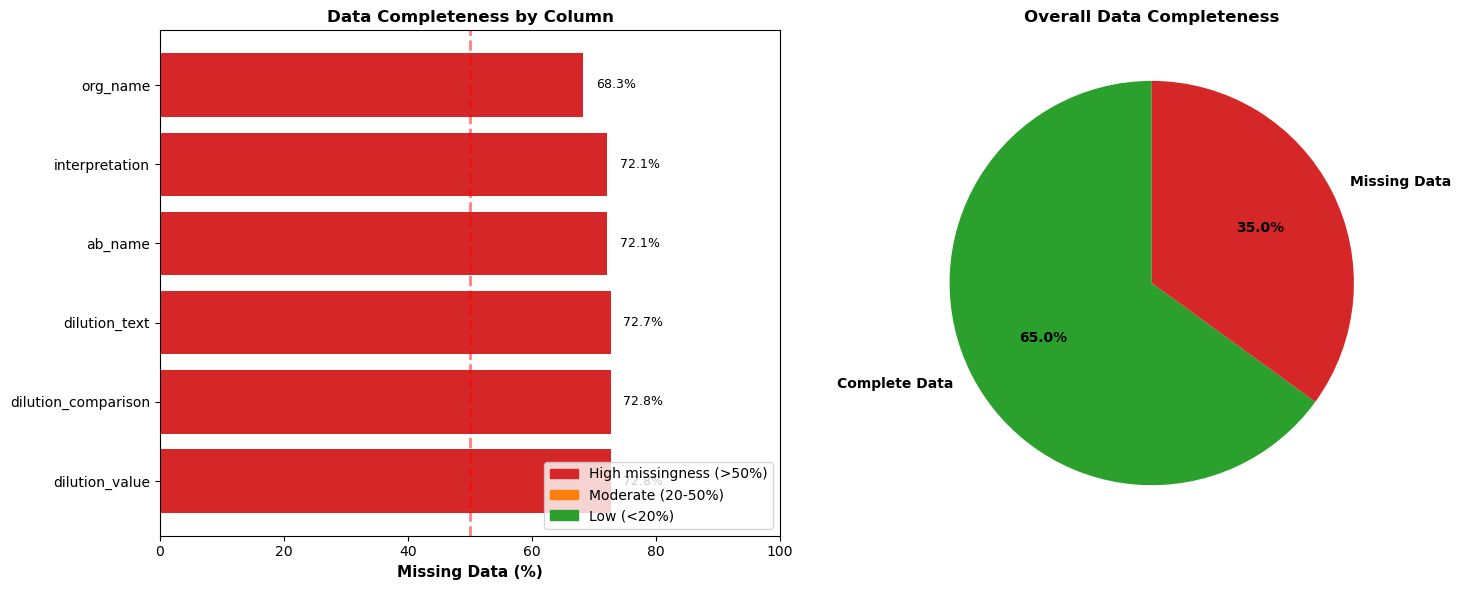

In [9]:
import matplotlib.patches as mpatches

# Calculate missing data
missing_data = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    'Column': missing_data.index,
    'Missing_Count': missing_data.values,
    'Missing_Percent': missing_percent.values
})

# Sort by percentage and filter non-zero
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    by='Missing_Percent', ascending=False
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
colors = ['#d62728' if x > 50 else '#ff7f0e' if x > 20 else '#2ca02c' 
          for x in missing_summary['Missing_Percent']]
ax1.barh(missing_summary['Column'], missing_summary['Missing_Percent'], color=colors)
ax1.set_xlabel('Missing Data (%)', fontsize=11, fontweight='bold')
ax1.set_title('Data Completeness by Column', fontsize=12, fontweight='bold')
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='50% threshold')
ax1.set_xlim(0, 100)

# Add percentage labels on bars
for i, v in enumerate(missing_summary['Missing_Percent']):
    ax1.text(v + 2, i, f'{v:.1f}%', va='center', fontsize=9)

# Pie chart: Data completeness overview
total_complete = len(df) * (df.shape[1] - len(missing_summary))
total_missing = missing_summary['Missing_Count'].sum()
complete_pct = 100 * total_complete / (total_complete + total_missing)

ax2.pie([complete_pct, 100 - complete_pct], 
        labels=['Complete Data', 'Missing Data'],
        autopct='%1.1f%%',
        colors=['#2ca02c', '#d62728'],
        startangle=90,
        textprops={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Overall Data Completeness', fontsize=12, fontweight='bold')

# Add legend
red_patch = mpatches.Patch(color='#d62728', label='High missingness (>50%)')
orange_patch = mpatches.Patch(color='#ff7f0e', label='Moderate (20-50%)')
green_patch = mpatches.Patch(color='#2ca02c', label='Low (<20%)')
ax1.legend(handles=[red_patch, orange_patch, green_patch], loc='lower right')

plt.tight_layout()
plt.show()

**Ecological Heatmap - Organisms vs Specimen Types**

Clinical Rationale: Validates biological consistency. We expect E. Coli primarily in urine and Staph Aureus in blood/wounds.

 Random patterns would indicate data quality issues.

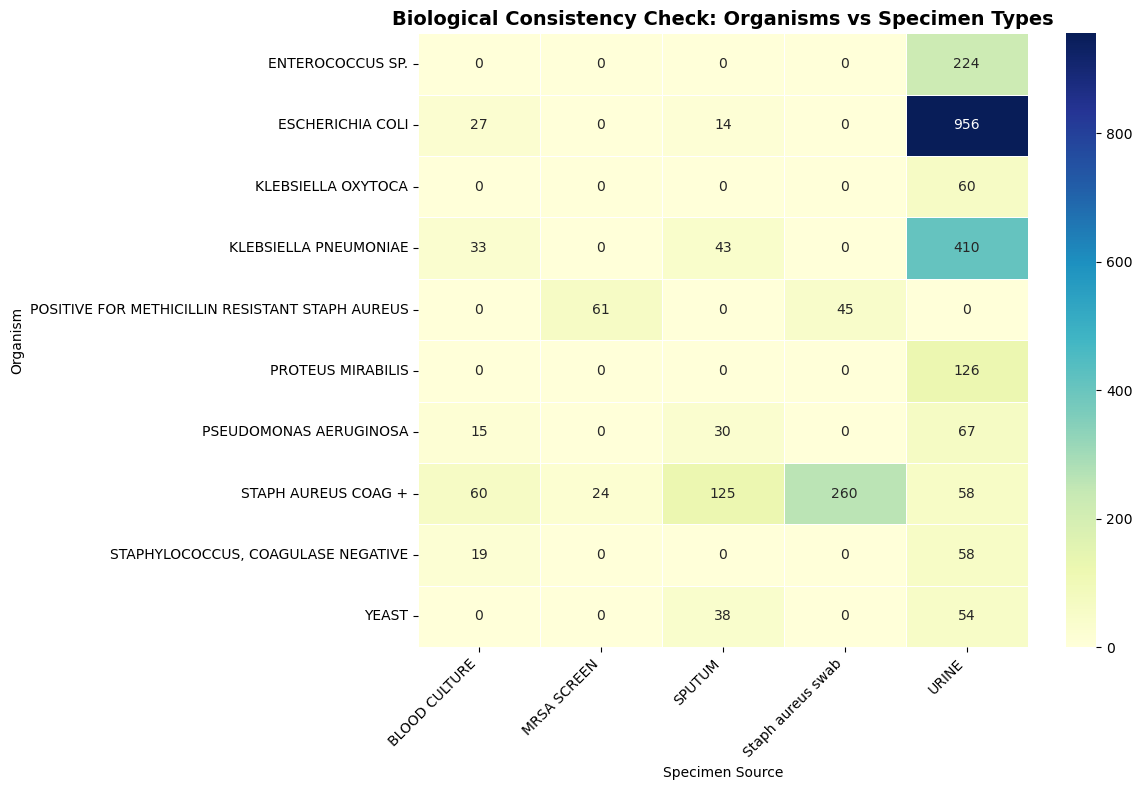

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select top 10 organisms and top 5 specimen types for readability
top_orgs = df['org_name'].value_counts().head(10).index
top_specs = df['spec_type_desc'].value_counts().head(5).index

# Filter dataset
subset = df[df['org_name'].isin(top_orgs) & df['spec_type_desc'].isin(top_specs)]

# Create cross-tabulation (contingency table)
cross_tab = pd.crosstab(subset['org_name'], subset['spec_type_desc'])

# Visualization
plt.figure(figsize=(12, 8))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Biological Consistency Check: Organisms vs Specimen Types', 
          fontsize=14, fontweight='bold')
plt.ylabel('Organism')
plt.xlabel('Specimen Source')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Clinical Interpretation**

**Dark Red**: High resistance (the antibiotic almost never works against that bacterium)

**Dark Green**: High sensitivity (the antibiotic is effective).

**Note**: Missing values ​​(white) indicate that the antibiotic has not been tested for that bacterium (intrinsic resistance or protocol).

**Population-Level Antibiogram - Resistance Map**

Reconstructs a population-level antibiogram. Visualizes which antibiotics are becoming ineffective against specific pathogens 

(red cells = clinical danger).

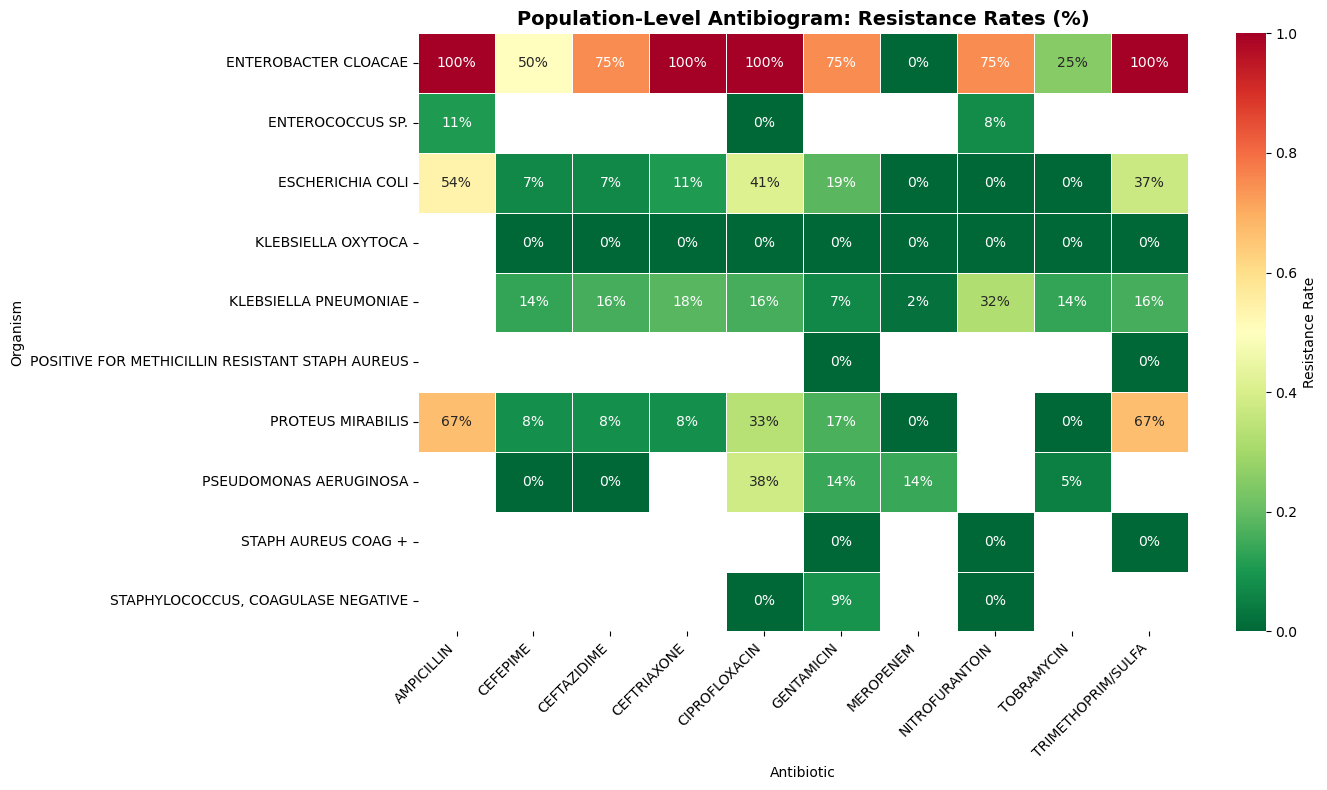

In [11]:
# Filter rows with valid interpretations and common organisms/antibiotics
res_df = df[df['interpretation'].isin(['S', 'R', 'I'])].copy()
res_df['is_resistant'] = res_df['interpretation'].apply(lambda x: 1 if x == 'R' else 0)

# Limit to top 10 organisms and top 10 most tested antibiotics
top_orgs_res = res_df['org_name'].value_counts().head(10).index
top_abs_res = res_df['ab_name'].value_counts().head(10).index

res_subset = res_df[res_df['org_name'].isin(top_orgs_res) & 
                     res_df['ab_name'].isin(top_abs_res)]

# Calculate average resistance rate
pivot_res = res_subset.pivot_table(index='org_name', columns='ab_name', 
                                     values='is_resistant', aggfunc='mean')

# Visualization
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_res, annot=True, fmt='.0%', cmap='RdYlGn_r', 
            linewidths=.5, vmin=0, vmax=1, cbar_kws={'label': 'Resistance Rate'})
plt.title('Population-Level Antibiogram: Resistance Rates (%)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Antibiotic')
plt.ylabel('Organism')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Dark Red**: High resistance (antibiotic rarely works on that bacterium).

**Dark Green**: High sensitivity (antibiotic is effective).

**White (missing)**: Antibiotic not tested for that organism (intrinsic resistance or protocol).

# Data Preparation

Based on the understanding phase, we now prepare the data. This involves:
1. **Dropping Redundant Columns**: Removing columns that do not add value or are redundant (e.g., `chartdate` vs `charttime`).
2. **Type Conversion**: Ensuring IDs are numeric and dates are datetime objects.
3. **Text Cleaning**: Standardizing categorical text data (stripping whitespace, normalizing case).
4. **Feature Engineering**: Creating clinically relevant features.

In [12]:
print("="*80)
print("DATA PREPARATION")
print("="*80)

# Drop redundant columns
columns_to_drop = ['chartdate', 'dilution_text']
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if len(columns_to_drop) > 0:
    df = df.drop(columns_to_drop, axis=1, errors='ignore')
    print(f"\n✓ Dropped {len(columns_to_drop)} redundant columns")

# Convert data types
print("\n Converting data types...")
df['subject_id'] = pd.to_numeric(df['subject_id'], errors='coerce')
df['hadm_id'] = df['hadm_id'].astype(int)
if 'charttime' in df.columns:
    df['charttime'] = pd.to_datetime(df['charttime'], errors='coerce')

# Convert categorical to string
categorical_cols = ['spec_type_desc', 'org_name', 'ab_name', 'interpretation', 'dilution_comparison']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('string')

print(" ✓ Data types converted")

# Text cleaning
print("\n🧹 Text cleaning...")
string_cols = df.select_dtypes(include='string').columns
for col in string_cols:
    df[col] = df[col].str.strip()

df.replace(['', ' ', 'NA', 'N/A', 'na', 'n/a'], pd.NA, inplace=True)

# Normalize to uppercase
if 'org_name' in df.columns:
    df['org_name'] = df['org_name'].str.upper()
if 'ab_name' in df.columns:
    df['ab_name'] = df['ab_name'].str.upper()
if 'interpretation' in df.columns:
    df['interpretation'] = df['interpretation'].str.upper()

print(" ✓ Text cleaning complete")

# ========================================================================
# SYNTHETIC SPECIMEN ID CREATION
# ========================================================================
# Since micro_specimen_id is missing, we create a surrogate key based on:
# hadm_id + spec_type_desc + charttime

df['pseudo_specimen_id'] = (
    df['hadm_id'].astype(str) + "_" + 
    df['spec_type_desc'].astype(str) + "_" + 
    df['charttime'].astype(str)
)

print(f"\n✓ Created 'pseudo_specimen_id' for grouping tests")
print(f" - Unique pseudo-specimens: {df['pseudo_specimen_id'].nunique():,}")

DATA PREPARATION

✓ Dropped 2 redundant columns

 Converting data types...
 ✓ Data types converted

🧹 Text cleaning...
 ✓ Text cleaning complete

✓ Created 'pseudo_specimen_id' for grouping tests
 - Unique pseudo-specimens: 6,552


**Operational Analysis - Hospital Sampling Workflow**

Samples are not random; they follow medical rounds (morning peaks) or emergency patterns. 

Understanding temporal distribution demonstrates comprehension of the data-generating process.

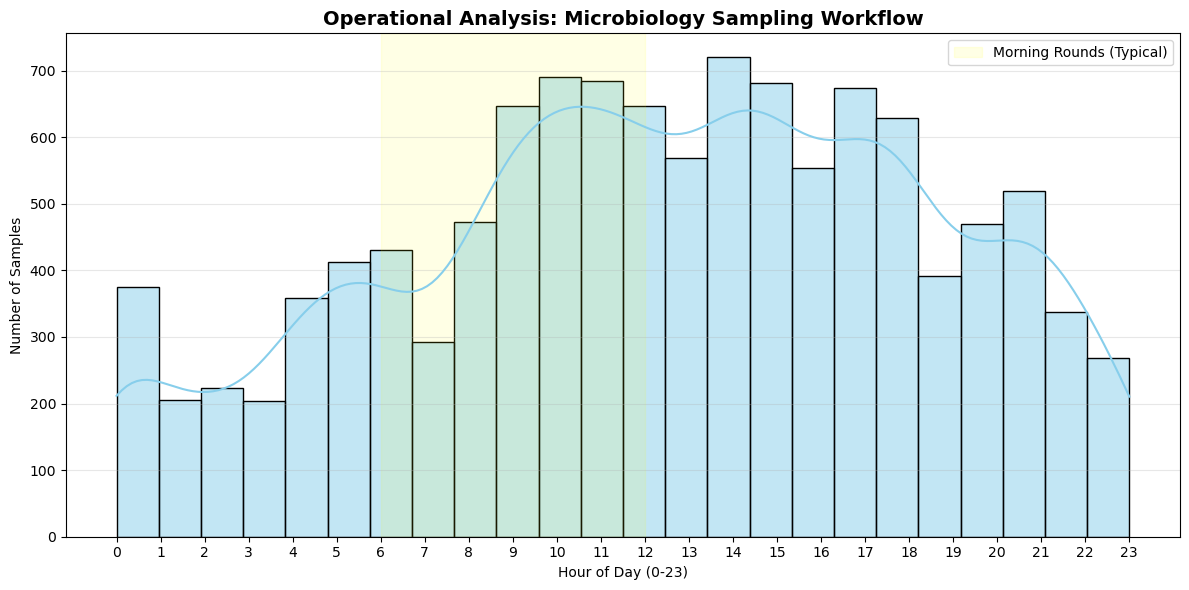

In [13]:
# Extract sampling hour
if 'charttime' in df.columns:
    df['sampling_hour'] = df['charttime'].dt.hour

    plt.figure(figsize=(12, 6))
    
    # Histogram of hours
    sns.histplot(df['sampling_hour'], bins=24, kde=True, color='skyblue', 
                 edgecolor='black', stat='count')
    
    plt.title('Operational Analysis: Microbiology Sampling Workflow', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Number of Samples')
    plt.xticks(range(0, 24))
    plt.grid(axis='y', alpha=0.3)
    
    # Highlight typical morning rounds
    plt.axvspan(6, 12, color='yellow', alpha=0.1, label='Morning Rounds (Typical)')
    plt.legend()
    plt.tight_layout()
    plt.show()


   **Operational Interpretation**
 - Peaks between `6:00-10:00` indicate routine sampling during medical rounds.
 - Uniform distribution would suggest emergency sampling or 24/7 ICU activity.

**MIC Dilution Value Distribution**

Understand the distribution of MIC (Minimum Inhibitory Concentration) values - a clinically critical parameter for antibiotic susceptibility testing

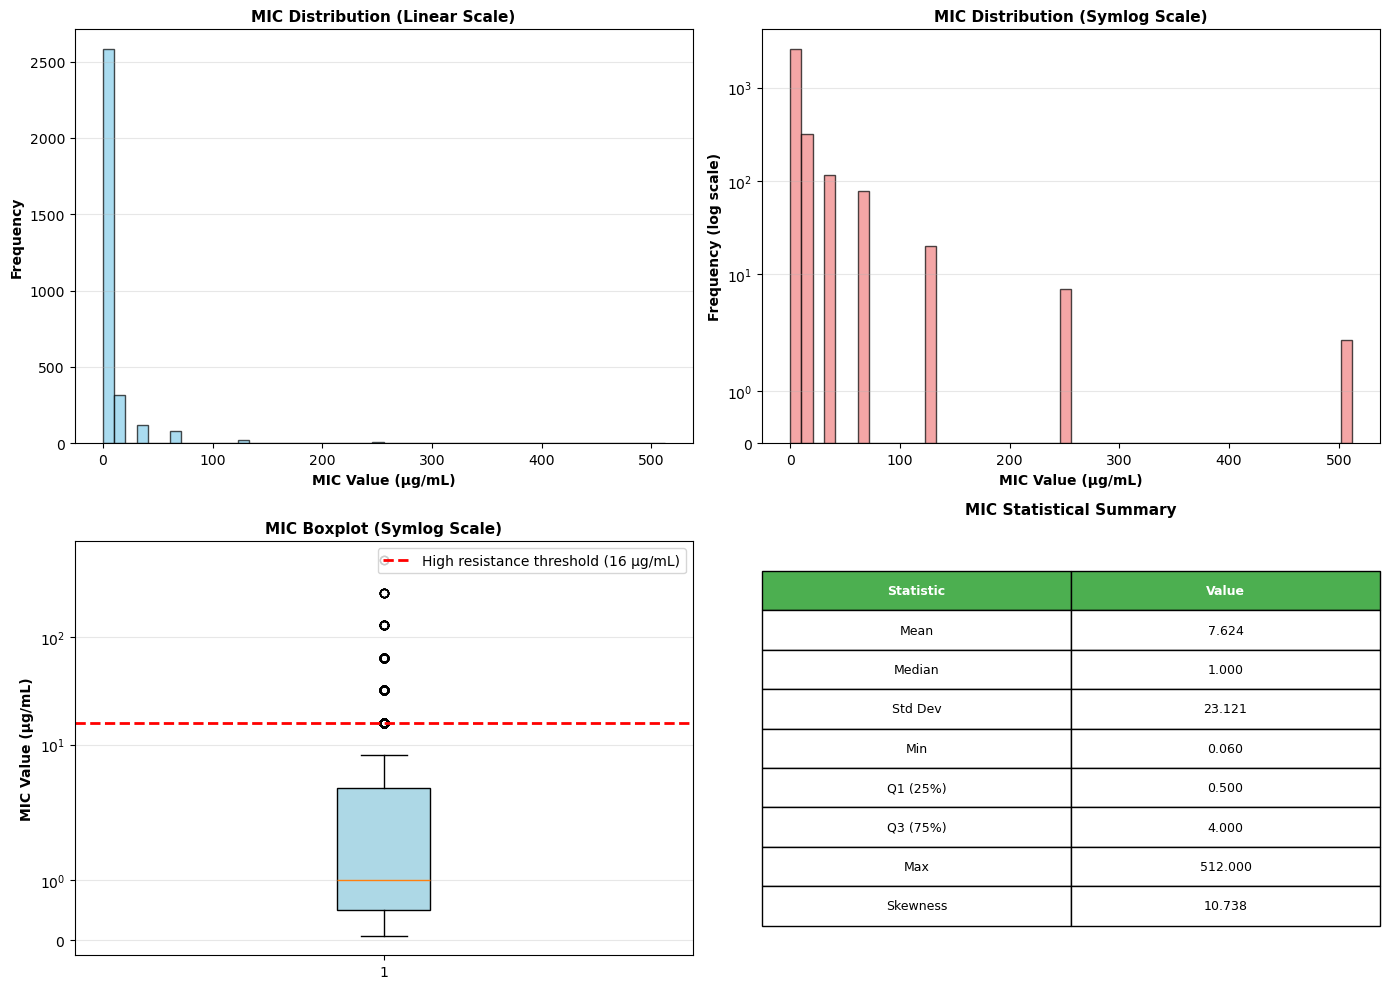

In [14]:
# Filter only rows with dilution values
dilution_df = df[df['dilution_value'].notna()].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram with KDE (Linear Scale)
ax1 = axes[0, 0]
ax1.hist(dilution_df['dilution_value'], bins=50, color='skyblue', 
         edgecolor='black', alpha=0.7)
ax1.set_xlabel('MIC Value (μg/mL)', fontsize=10, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax1.set_title('MIC Distribution (Linear Scale)', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Histogram with Symlog Scale (better for skewed data)
ax2 = axes[0, 1]
ax2.hist(dilution_df['dilution_value'], bins=50, color='lightcoral', 
         edgecolor='black', alpha=0.7)
ax2.set_yscale('symlog')
ax2.set_xlabel('MIC Value (μg/mL)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Frequency (log scale)', fontsize=10, fontweight='bold')
ax2.set_title('MIC Distribution (Symlog Scale)', 
              fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

# 3. Boxplot with Symlog Scale
ax3 = axes[1, 0]
bp = ax3.boxplot(dilution_df['dilution_value'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
ax3.set_ylabel('MIC Value (μg/mL)', fontsize=10, fontweight='bold')
ax3.set_yscale('symlog')
ax3.set_title('MIC Boxplot (Symlog Scale)', fontsize=11, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

# Add clinical threshold line (MIC=16: typical high resistance threshold)
ax3.axhline(y=16, color='red', linestyle='--', linewidth=2, label='High resistance threshold (16 μg/mL)')
ax3.legend()

# 4. Summary Statistics Table
ax4 = axes[1, 1]
ax4.axis('off')

stats = {
    'Mean': dilution_df['dilution_value'].mean(),
    'Median': dilution_df['dilution_value'].median(),
    'Std Dev': dilution_df['dilution_value'].std(),
    'Min': dilution_df['dilution_value'].min(),
    'Q1 (25%)': dilution_df['dilution_value'].quantile(0.25),
    'Q3 (75%)': dilution_df['dilution_value'].quantile(0.75),
    'Max': dilution_df['dilution_value'].max(),
    'Skewness': dilution_df['dilution_value'].skew(),
}

table_data = [[k, f'{v:.3f}'] for k, v in stats.items()]
table = ax4.table(cellText=table_data, colLabels=['Statistic', 'Value'],
                  cellLoc='center', loc='center', colWidths=[0.5, 0.5])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Color header
for i in range(2):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax4.set_title('MIC Statistical Summary', fontsize=11, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()


**MIC Dilution Value Analysis**

High MIC values indicate RESISTANCE to that antibiotic,  these outliers are CLINICALLY MEANINGFUL and must be PRESERVED

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11458 entries, 0 to 15284
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   subject_id           11458 non-null  int64         
 1   hadm_id              11458 non-null  int64         
 2   charttime            11458 non-null  datetime64[ns]
 3   spec_type_desc       11458 non-null  string        
 4   test_name            11458 non-null  object        
 5   org_name             3634 non-null   string        
 6   ab_name              3195 non-null   string        
 7   dilution_comparison  3122 non-null   string        
 8   dilution_value       3122 non-null   float64       
 9   interpretation       3195 non-null   string        
 10  technician_id        11458 non-null  object        
 11  qc_flag              11458 non-null  object        
 12  pseudo_specimen_id   11458 non-null  object        
 13  sampling_hour        11458 non-null 

# 3. Feature Extraction

We extract features relevant to infection severity and resistance. 

**Core Features Strategy:**
1. **Infection Presence**: Identifying if an infection is present (`infection_present`, `num_positive_cultures`).
2. **Critical Sites**: Identifying high-risk infections like bacteremia (`bacteremia`, `respiratory_infection`).
3. **Resistance**: Identifying Multi-Drug Resistant (MDR) organisms (`mdr_organism`, `resistance_rate`).
4. **Severity**: Creating a composite score based on clinical factors (`infection_severity_score`).

In [16]:
def is_mdr_organism(organism_name):
    """Identify multi-drug resistant organisms (MRSA, VRE, ESBL, CRE)."""
    if pd.isna(organism_name):
        return False
    
    org = str(organism_name).upper()
    
    mdr_patterns = [
        'MRSA', 'METHICILLIN RESISTANT',
        'VRE', 'VANCOMYCIN RESISTANT',
        'ESBL', 'EXTENDED SPECTRUM',
        'CRE', 'CARBAPENEM RESISTANT',
        'MDR', 'MULTI-DRUG RESISTANT', 'MULTIDRUG RESISTANT'
    ]
    
    return any(pattern in org for pattern in mdr_patterns)

def classify_specimen_type(spec_desc):
    """Classify specimen into major clinical categories."""
    if pd.isna(spec_desc):
        return 'UNKNOWN'
    
    spec = str(spec_desc).upper()
    
    if any(x in spec for x in ['BLOOD', 'HEMOCULTURE']):
        return 'BLOOD'
    elif any(x in spec for x in ['URINE', 'URINARY']):
        return 'URINE'
    elif any(x in spec for x in ['SPUTUM', 'RESPIRATORY', 'BRONCH', 'BAL', 'TRACHEAL']):
        return 'RESPIRATORY'
    elif any(x in spec for x in ['WOUND', 'ABSCESS', 'TISSUE']):
        return 'WOUND'
    else:
        return 'OTHER'

print("✓ Classification functions defined")

# Apply classifications
if 'org_name' in df.columns:
    df['is_mdr'] = df['org_name'].apply(is_mdr_organism)
    
if 'spec_type_desc' in df.columns:
    df['specimen_category'] = df['spec_type_desc'].apply(classify_specimen_type)

✓ Classification functions defined


In [17]:
admission_features = []

for (subject_id, hadm_id), group in df.groupby(['subject_id', 'hadm_id']):
    features = {
        'subject_id': subject_id,
        'hadm_id': hadm_id
    }
    
    # 1. INFECTION PRESENCE (3 features)
    
    # Any positive culture (organism identified)
    if 'org_name' in group.columns:
        positive_cultures = group[group['org_name'].notna()]
        features['num_positive_cultures'] = len(positive_cultures) if len(positive_cultures) > 0 else 0
        features['num_unique_organisms'] = positive_cultures['org_name'].nunique()
    else:
        features['num_positive_cultures'] = 0
        features['num_unique_organisms'] = 0
    
    # 2. CRITICAL INFECTION SITES (2 features)
    
    if 'specimen_category' in group.columns and 'org_name' in group.columns:
        positive_specimens = group[group['org_name'].notna()]['specimen_category'].unique()
        features['bacteremia'] = 1 if 'BLOOD' in positive_specimens else 0
        features['respiratory_infection'] = 1 if 'RESPIRATORY' in positive_specimens else 0
    else:
        features['bacteremia'] = 0
        features['respiratory_infection'] = 0
    
    # 3. ANTIMICROBIAL RESISTANCE (2 features)
    
    # MDR organism present
    if 'is_mdr' in group.columns:
        features['mdr_organism'] = 1 if group['is_mdr'].any() else 0
    else:
        features['mdr_organism'] = 0
    
    # Resistance rate
    if 'interpretation' in group.columns:
        interp_data = group['interpretation'].dropna()
        if len(interp_data) > 0:
            resistant_count = (interp_data == 'R').sum()
            features['resistance_rate'] = (resistant_count / len(interp_data)).round(3)
        else:
            features['resistance_rate'] = 0
    else:
        features['resistance_rate'] = 0
    
    # 4. INFECTION SEVERITY (3 features)
    
    # Polymicrobial infection (using pseudo_specimen_id)
    if 'pseudo_specimen_id' in group.columns and 'org_name' in group.columns:
        orgs_per_specimen = group[group['org_name'].notna()].groupby('pseudo_specimen_id')['org_name'].nunique()
        features['polymicrobial'] = 1 if (orgs_per_specimen > 1).any() else 0
    else:
        features['polymicrobial'] = 0
    
    # Multi-site infection (≥2 different positive specimen types)
    if 'specimen_category' in group.columns and 'org_name' in group.columns:
        positive_site_count = group[group['org_name'].notna()]['specimen_category'].nunique()
        features['multisite_infection'] = 1 if positive_site_count >= 2 else 0
    else:
        features['multisite_infection'] = 0
    
    # Infection Severity Score (0-10)
    severity = 0
    severity += features['bacteremia'] * 4          # Bloodstream infection (highest risk)
    severity += features['polymicrobial'] * 2       # Multiple organisms
    severity += features['mdr_organism'] * 2        # Drug resistance
    severity += features['multisite_infection'] * 2 # Multiple infection sites
    
    features['infection_severity_score'] = min(severity, 10)
    
    admission_features.append(features)

# Create DataFrame
df_features = pd.DataFrame(admission_features)

#We can drop the intermediate columns (we've the score already)
df_features = df_features.drop(columns=['num_positive_cultures', 'num_unique_organisms',
                                        'bacteremia', 'respiratory_infection',
                                        'mdr_organism', 'resistance_rate',
                                        'polymicrobial', 'multisite_infection'])
print(f"\n✓ Feature extraction complete")
print(f" - Admissions processed: {len(df_features):,}")
print(f" - Features per admission: {df_features.shape[1]}")

print(f"\n{'='*80}")
print("EXTRACTED FEATURES")
print("="*80)
feature_cols = [col for col in df_features.columns if col not in ['subject_id', 'hadm_id']]
for i, col in enumerate(feature_cols, 1):
    print(f" {i:2d}. {col}")


✓ Feature extraction complete
 - Admissions processed: 2,198
 - Features per admission: 3

EXTRACTED FEATURES
  1. infection_severity_score



**Severity Score Distribution**

Validates the composite feature `infection_severity_score`. 

If all patients had score 10 or 0, the feature would be useless for clustering. 
Varied distribution confirms utility for patient segmentation.

In [18]:
df_features.nunique()

subject_id                  2082
hadm_id                     2198
infection_severity_score       6
dtype: int64

/tmp/ipykernel_61907/1047694659.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='infection_severity_score', data=df_features,


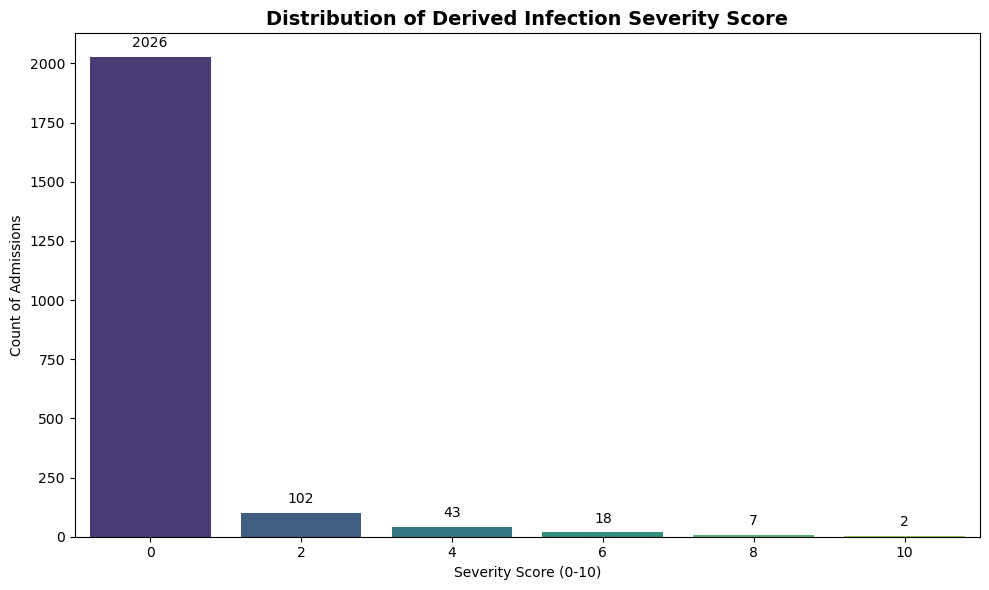

In [19]:
# Visualization of severity score distribution
if 'infection_severity_score' in df_features.columns:
    plt.figure(figsize=(10, 6))
    
    # Countplot for discrete score distribution
    ax = sns.countplot(x='infection_severity_score', data=df_features, 
                       palette='viridis', order=sorted(df_features['infection_severity_score'].unique()))
    
    plt.title('Distribution of Derived Infection Severity Score', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Severity Score (0-10)')
    plt.ylabel('Count of Admissions')
    
    # Add count labels above bars
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 10), 
                    textcoords='offset points')
    
    plt.tight_layout()
    plt.show()

 **Feature Validation**
- Score `0`: Patients with no detected infection.
- Right tail (Score > `5`): Critical patients (candidates for high-risk cluster).

In [20]:
skewness_score = df_features['infection_severity_score'].skew()
print("Skewness of infection_severity_score:")
print(skewness_score)

Skewness of infection_severity_score:
4.962623998285266


In [21]:
output_file = "microbiology_events_features.csv"
df_features.to_csv(Path().resolve().parent / 'Features' / output_file, index=False)

print(f"\n✓ Successfully saved: {output_file}")
print(f" - Admissions: {len(df_features):,}")
print(f" - Unique patients: {df_features['subject_id'].nunique():,}")
print(f" - Features per admission: {df_features.shape[1]}")


✓ Successfully saved: microbiology_events_features.csv
 - Admissions: 2,198
 - Unique patients: 2,082
 - Features per admission: 3
